In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

In [4]:
e = 1.6e-19
mp = 1.67e-27
me = 9.1e-31

In [26]:
def build_grid(energy_eV, theta_deg, phi_deg):

    E = np.asarray(energy_eV, float)
    theta = np.deg2rad(np.asarray(theta_deg, float))
    phi = np.deg2rad(np.asarray(phi_deg, float))

    v = np.sqrt(2.0 * e * E) / mp

    logE = np.log(E)
    dE_over_E = np.gradient(logE)

    v = 0.5 * v * dE_over_E

    dtheta = np.abs(np.gradient(theta))
    dphi = np.abs(np.gradient(phi))

    st, ct = np.sin(theta), np.cos(theta)
    sp, cp = np.sin(phi), np.cos(phi)

    ex = st[:, None] * cp[None, :]
    ey = st[:, None] * sp[None, :]
    ez = np.broadcast_to(ct[:, None], ex.shape)

    ehat = np.stack([ex, ey, ez], axis=-1)

    dOmega = (st[:, None] * dtheta[:, None] * dphi[None, :])

    dV = (v**2 * dv)[:, None, None] * dOmega[None, :, :]

    vvec = v[:, None, None, None] * ehat[None, :, :, :]

    return dict(v=v, dv=dv, ehat=ehat, dOmega=dOmega, dV=dV, vvec=vvec)

In [27]:
nE = 32
ntheta = 16
nphi = 32

Emin = 10
Emax = 30000

E = np.geomspace(Emin, Emax, nE)
theta = np.linspace(0.0, 360.0, ntheta)
phi = np.linspace(0.0, 180.0, nphi)

grid = build_grid(E, theta, phi)

In [44]:
n_true = 5e6
V_true = np.array([-200e3, 50e3, 0.0])
T_true = 300.0

vth2 = 2*e*T_true/mp

dv = grid['vvec'] - V_true

f_true = n_true * (np.pi * vth2) ** -1.5 * np.exp(-np.sum(dv**2, axis=-1) / vth2)


In [48]:
rng = np.random.default_rng(0)

G = 1e-30
dtau = 0.03
lam = f_true * G * dtau * (grid['v'] ** 4)[:, None, None]
counts = rng.poisson(np.maximum(lam, 0)).astype(float)


In [49]:
counts

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

self-check f at drift center: 0.000e+00


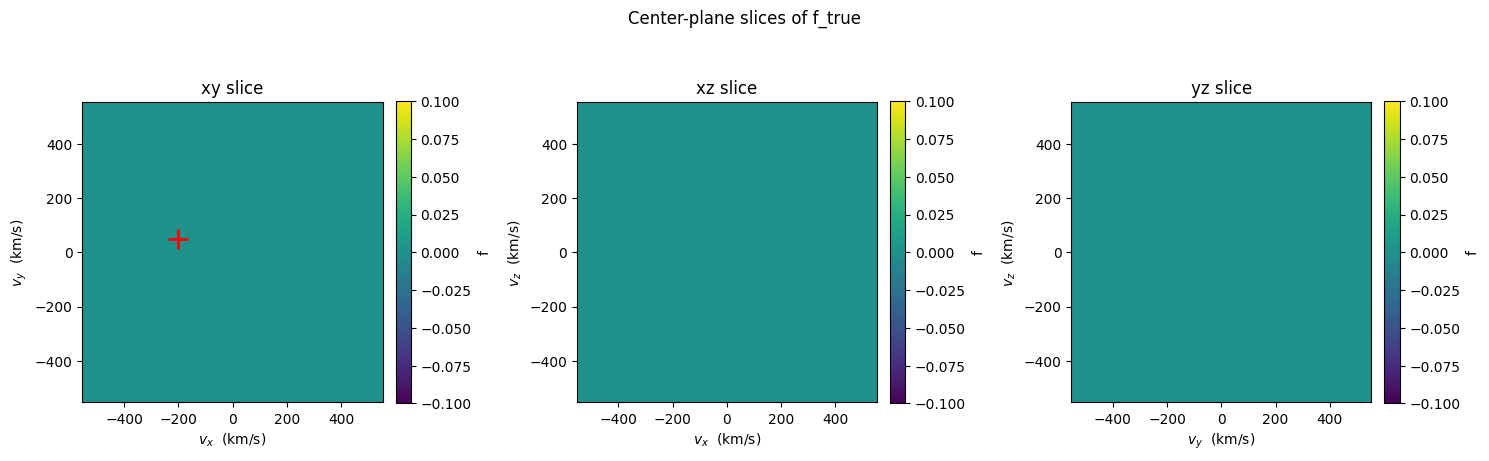

In [51]:
km = 1e3

E = np.asarray(E, float)
th = np.deg2rad(theta)
ph = np.deg2rad(phi)
F = f_true.copy()
 
def _ascending(axis, arr, ax_index):
    if axis[0] > axis[-1]:
        order = np.argsort(axis)
        return axis[order], np.take(arr, order, axis=ax_index)
    return axis, arr
 
E, F = _ascending(E, F, 0)
th, F = _ascending(th, F, 1)
ph, F = _ascending(ph, F, 2)
 
interp = RegularGridInterpolator((E, th, ph), F,
                                 bounds_error=False, fill_value=0.0)
 
def f_at_cartesian(VX, VY, VZ):
    """f_true evaluated at Cartesian velocity components (m/s)."""
    speed = np.sqrt(VX**2 + VY**2 + VZ**2)
    En = 0.5 * mp * speed**2 / e                          # eV
    safe = np.where(speed > 0, speed, 1.0)
    Th = np.arccos(np.clip(VZ / safe, -1, 1))
    Ph = np.mod(np.arctan2(VY, VX), 2 * np.pi)
    pts = np.column_stack([En.ravel(), Th.ravel(), Ph.ravel()])
    return interp(pts).reshape(VX.shape)
 
# self-check: nonzero at the drift center means units/axes are consistent
_sp = np.sqrt(np.sum(V_true**2)) or 1.0
_probe = f_at_cartesian(np.array([[V_true[0]]]),
                        np.array([[V_true[1]]]),
                        np.array([[V_true[2]]]))[0, 0]
print("self-check f at drift center: %.3e" % _probe)
if _probe < 1e-3 * F.max():
    print("  WARNING: near-zero -- check `energy` units (must be eV) and axis order.")
 
# ==========================================================================
# FIGURE 1 -- three orthogonal center-plane slices
# ==========================================================================
lim = 550e3
gc = np.linspace(-lim, lim, 160)
A, B = np.meshgrid(gc, gc, indexing='ij')
Vx0, Vy0, Vz0 = V_true
 
fig1, axes = plt.subplots(1, 3, figsize=(15, 4.6))
planes = [
    ('xy', (A, B, np.full_like(A, Vz0)), r'$v_x$', r'$v_y$'),
    ('xz', (A, np.full_like(A, Vy0), B), r'$v_x$', r'$v_z$'),
    ('yz', (np.full_like(A, Vx0), A, B), r'$v_y$', r'$v_z$'),
]
for ax, (name, coords, xl, yl) in zip(axes, planes):
    S = f_at_cartesian(*coords)
    pcm = ax.pcolormesh(A / km, B / km, S, cmap='viridis', shading='auto')
    ax.contour(A / km, B / km, S, levels=6, colors='white', linewidths=0.5, alpha=0.5)
    ax.set_xlabel(f'{xl}  (km/s)')
    ax.set_ylabel(f'{yl}  (km/s)')
    ax.set_title(f'{name} slice')
    ax.set_aspect('equal')
    fig1.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04, label='f')
axes[0].plot(Vx0 / km, Vy0 / km, 'r+', ms=14, mew=2)
fig1.suptitle('Center-plane slices of f_true', y=1.02)
fig1.tight_layout()


In [53]:
S[S!=0]

array([], dtype=float64)